In [1]:
# 1. 파이썬 코드에서 Matplotlib 폰트 설정
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import numpy as np
from datetime import timedelta
from itertools import combinations
from collections import Counter

# 폰트 설정
plt.rc('font', family='Malgun Gothic')
# 마이너스 부호 깨짐 방지
plt.rcParams['axes.unicode_minus'] = False

print("한글 폰트 설정이 완료되었습니다.")

# 3. 데이터 로드 및 통합 (모든 문제 풀이의 시작점)
try:
    orders_df = pd.read_csv('../data/orders.csv')
    payments_df = pd.read_csv('../data/payments.csv')
    products_df = pd.read_csv('../data/products.csv')
    shipping_df = pd.read_csv('../data/shipping.csv')
    customers_df = pd.read_csv('../data/customers.csv')

    # 모든 데이터프레임 병합
    df = pd.merge(orders_df, payments_df, on='order_id', how='left')
    df = pd.merge(df, products_df, on='product_id', how='left')
    df = pd.merge(df, customers_df, on='customer_id', how='left')
    df = pd.merge(df, shipping_df, on='order_id', how='left')

    # 데이터 전처리
    date_cols = ['order_date', 'payment_date', 'join_date', 'shipping_start_date', 'shipping_end_date']
    for col in date_cols:
        df[col] = pd.to_datetime(df[col], errors='coerce')
    df['total_sales'] = df['quantity'] * df['price']
    
    print("데이터 로드 및 통합이 완료되었습니다.")

except FileNotFoundError as e:
    print(f"파일을 찾을 수 없습니다: {e}")


한글 폰트 설정이 완료되었습니다.
데이터 로드 및 통합이 완료되었습니다.


In [2]:
# 문제 6: 성별과 연령대를 조합하여 (예: '20대 남성'), 각 그룹의 평균 주문액(AOV)을 비교하세요.
# 시각화: 히트맵

# 비즈니스 목적: 보다 세분화된 고객 그룹(세그먼트)의 특징을 분석하고, 특정 그룹에 대한 타겟 마케팅 전략의 효과를 극대화합니다.

# 출력 결과를 보고 코딩하세요

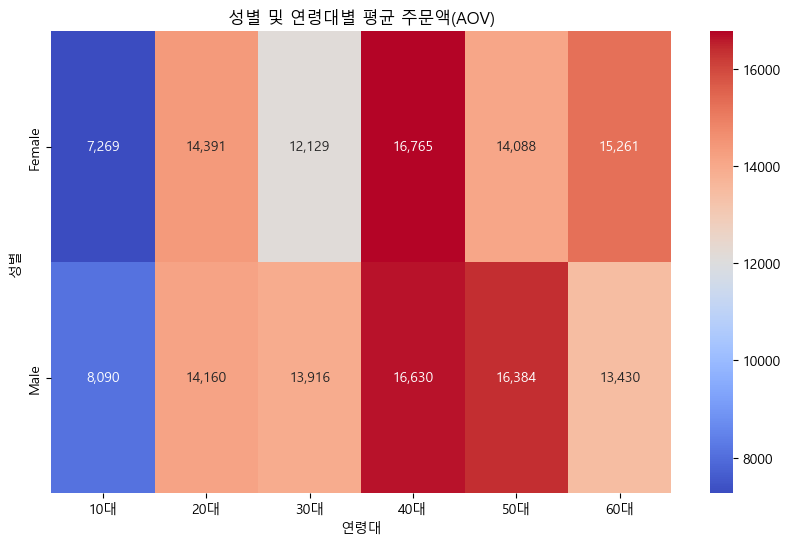



In [3]:
# 나와야 하는 데이터 : 연령대 그룹, 성별, 성별 및 연령대별 평균 주문액(AOV)

# 현재 있는 데이터 : gender(성별), age(고객 나이) , total_sales(총 주문액), order_id(주문 ID)
# quantity(주문 수량)

# 추가로 만들어야 하는 데이터 : age_group(연령대 그룹), AOV(평균 주문액)

# 70대 이상 데이터 불균형 때문에 제외


In [ ]:
# 1) age 컬럼을 숫자형으로 안전 변환
# df['age']는 Series; to_numeric은 변환된 Series 반환. 변환 실패 시 NaN으로 표시.
df['age'] = pd.to_numeric(df['age'], errors='coerce')

# 2) 연령대 변환 함수 정의 (70대 이상은 제외 -> None 반환)
def to_age_group_no_70(age):
    # 입력 age: 숫자 또는 NaN; 반환: 문자열(예: '20대') 또는 None
    if pd.isna(age):
        return None
    try:
        age = int(age)
    except Exception:
        return None
    if 10 <= age < 20:
        return '10대'
    if 20 <= age < 30:
        return '20대'
    if 30 <= age < 40:
        return '30대'
    if 40 <= age < 50:
        return '40대'
    if 50 <= age < 60:
        return '50대'
    if 60 <= age < 70:
        return '60대'
    # 70 이상은 None -> 이후 분석에서 제외됨
    return None

# 3) age_group 컬럼 생성 (Series를 DataFrame에 추가)
df['age_group'] = df['age'].apply(to_age_group_no_70)

# 4) 연령대가 지정된 행만 필터링하여 별도 DataFrame 생성
# df_age_filtered는 DataFrame; 원본 df는 변경되지 않음(copy 사용으로 안전)
df_age_filtered = df[df['age_group'].notna()].copy()

# 5) gender 값 정리 (Series 연산)
# 문자열을 통일 ('Male','Female' 형태). 그 외는 'Unknown'으로 표준화.
df_age_filtered['gender'] = df_age_filtered['gender'].astype(str).str.strip().str.title()
df_age_filtered.loc[~df_age_filtered['gender'].isin(['Male', 'Female']), 'gender'] = 'Unknown'

# 6) total_sales 보정: 컬럼이 없으면 quantity * price로 생성
if 'total_sales' not in df_age_filtered.columns:
    # quantity, price는 Series. to_numeric으로 안전 변환 후 NaN->0 처리
    df_age_filtered['quantity'] = pd.to_numeric(df_age_filtered['quantity'], errors='coerce').fillna(0)
    df_age_filtered['price'] = pd.to_numeric(df_age_filtered['price'], errors='coerce').fillna(0)
    # total_sales는 Series(숫자) 생성
    df_age_filtered['total_sales'] = df_age_filtered['quantity'] * df_age_filtered['price']

# 7) 성별(gender) 및 연령대(age_group)별 평균 주문액(AOV) 계산 (pivot_table 결과는 DataFrame)
aov_pivot = df_age_filtered.pivot_table(
    index='gender',                # 결과 DataFrame의 인덱스(행)로 gender 사용
    columns='age_group',           # 결과 DataFrame의 컬럼(열)으로 age_group 사용
    values='total_sales',          # 집계 대상 Series
    aggfunc='mean',                # 평균 계산 (AOV)
    dropna=True                    # 완전히 NaN인 그룹은 제거
)

# 8) 연령대 컬럼 순서 재정렬 (10대~60대). 존재하는 컬럼만 선택.
desired_order = ['10대', '20대', '30대', '40대', '50대', '60대']
cols_in_order = [c for c in desired_order if c in aov_pivot.columns]
aov_pivot = aov_pivot.reindex(columns=cols_in_order)

# 9) 성별 행 순서 재정렬: Male, Female, (Unknown 있으면 뒤에 추가)
desired_gender_order = ['Male', 'Female']
genders_present = [g for g in desired_gender_order if g in aov_pivot.index]
if 'Unknown' in aov_pivot.index:
    genders_present.append('Unknown')
aov_pivot = aov_pivot.reindex(index=genders_present)

# 계산 파트 결과: aov_pivot (pandas DataFrame)
# aov_pivot.index -> 성별 리스트 (예: ['Male','Female',...])
# aov_pivot.columns -> 연령대 리스트 (예: ['10대','20대',...'])
# aov_pivot.loc['Male','30대'] 같은 방식으로 평균 주문액(숫자)에 접근 가능

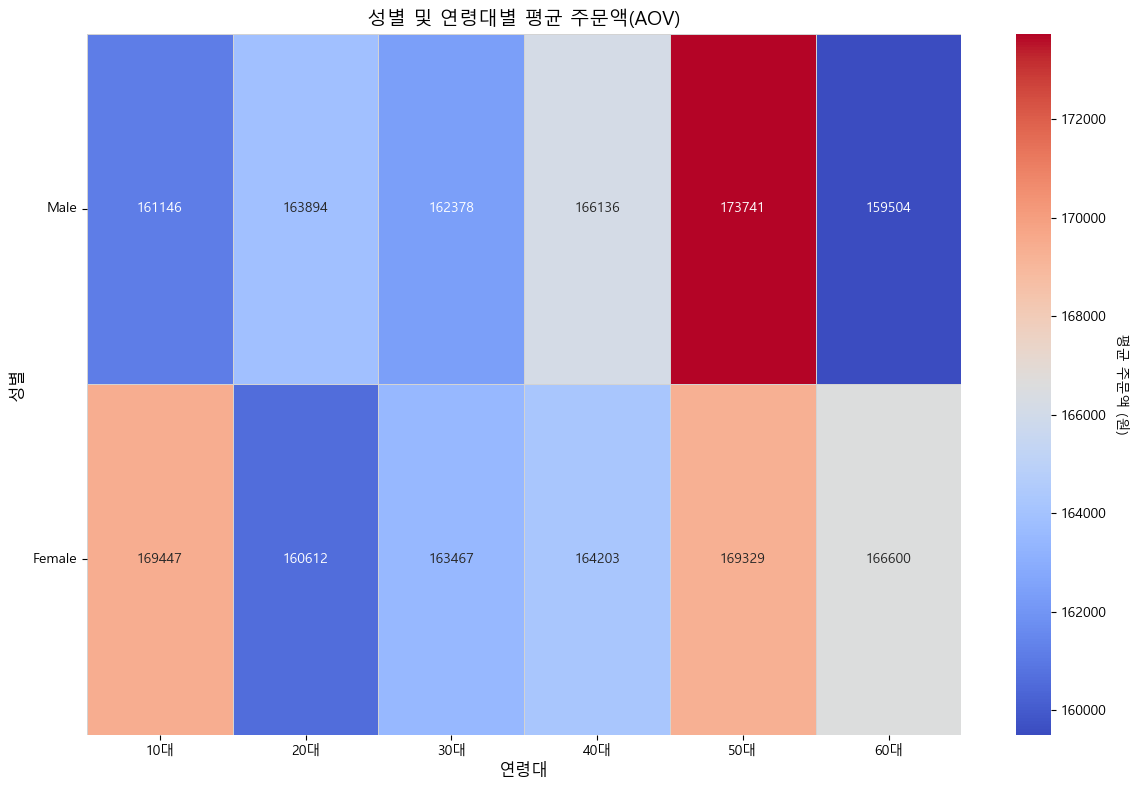

In [5]:
# 시각화 파트 시작
import matplotlib.pyplot as plt    # 모듈: matplotlib.pyplot (Figure, Axes)
import seaborn as sns              # 모듈: seaborn (통계 시각화)

# 1) 한글 폰트 및 마이너스 기호 안전 설정 (plt/Seaborn 동시 적용)
# plt.rc('font', family='Malgun Gothic')               # matplotlib에 폰트 설정
# plt.rcParams['axes.unicode_minus'] = False           # 마이너스 깨짐 방지
# sns.set(font='Malgun Gothic', rc={'axes.unicode_minus': False})

# 2) 컬러맵 준비: 파랑 -> 빨강 그라데이션 (coolwarm)
cmap = sns.color_palette("coolwarm", as_cmap=True)  # matplotlib 호환 컬러맵

# 3) Figure 생성 (matplotlib Figure 객체)
plt.figure(figsize=(12, 8))  # 가로12인치 x 세로8인치

# 4) 히트맵 그리기 (입력: aov_pivot DataFrame)
# 반환값 ax는 matplotlib Axes 객체
ax = sns.heatmap(
    aov_pivot,            # 입력 DataFrame: 행=gender, 열=age_group, 값=AOV
    annot=True,           # 각 셀에 수치 표기 (텍스트)
    fmt='.0f',            # 정수 형태로 표시 (예: 12345)
    cmap=cmap,            # 지정한 컬러맵 적용 (파랑->빨강)
    cbar=True,            # 오른쪽 컬러바(범례) 표시
    linewidths=0.5,       # 셀 경계선 굵기
    linecolor='lightgray' # 셀 경계선 색상
)

# 5) 제목 및 축 라벨 설정 (Axes 메서드)
ax.set_title('성별 및 연령대별 평균 주문액(AOV)', fontsize=14)  # 타이틀
ax.set_xlabel('연령대', fontsize=12)                           # X축 라벨
ax.set_ylabel('성별', fontsize=12)                             # Y축 라벨

# 6) 틱(레이블) 회전 및 정렬
ax.set_xticklabels(ax.get_xticklabels(), rotation=0)  # X축 레이블 수평 배치(0도)
ax.set_yticklabels(ax.get_yticklabels(), rotation=0)  # Y축 레이블 수평 배치(0도)

# 7) 컬러바 레이블 추가 (matplotlib Colorbar 객체 접근)
cbar = ax.collections[0].colorbar
cbar.set_label('평균 주문액 (원)', rotation=270, labelpad=15)  # 컬러바 라벨을 세로로 표시

# 8) 레이아웃 조정 및 출력
plt.tight_layout()  # 여백 자동 조정
plt.show()          # 그래프 렌더링

In [6]:
# # -------------------------------------------
# # age_group이 없다면 만들어야 함
# # age 컬럼(나이)에서 연령대를 추출

# # df['age']: 컬럼 (나이 숫자, 예: 25, 34, 52)
# # // 10: 10으로 나눈 몫 (25 → 2, 34 → 3, 52 → 5)
# # * 10: 다시 10 곱하기 (2 → 20, 3 → 30, 5 → 50)
# # f"{...}대": 문자열 만들기 ("20대", "30대", "50대")
# df['age_group'] = (df['age'] // 10 * 10).astype(str) + '대'
# # df['age_group']: 새로 만든 컬럼 (예: "20대", "30대")

# # 확인용 출력
# print("연령대 생성 확인:")
# print(df[['age', 'age_group']].head(10))
# # df[['age', 'age_group']]: 두 컬럼만 선택
# # .head(10): 첫 10개 행만 출력
# print("\n")

# # -------------------------------------------
# # Step 2: 70대 이상 제거
# # -------------------------------------------
# # 70대, 80대 등은 필터링으로 제거

# # df['age'] < 70: 조건 (나이가 70 미만인가?)
# # df[조건]: 조건이 True인 행만 선택
# df_filtered = df[df['age'] < 70].copy()
# # df_filtered: 변수 (70세 미만만 담긴 새 데이터프레임)
# # .copy(): 원본 건드리지 않고 복사본 만들기

# print(f"전체 데이터: {len(df)}개")
# print(f"70세 미만: {len(df_filtered)}개")
# print(f"제거된 데이터: {len(df) - len(df_filtered)}개")
# print("\n")

# # -------------------------------------------
# # Step 3: 성별 × 연령대별 평균 주문액 계산
# # -------------------------------------------

# # pivot_table: 긴 데이터를 표(가로×세로) 형태로 변환
# aov_table = df_filtered.pivot_table(
#     values='total_sales',        # 값: 평균 낼 컬럼 (주문액)
#     index='gender',              # 인덱스(세로축): 성별
#     columns='age_group',         # 컬럼(가로축): 연령대
#     aggfunc='mean'               # 집계 함수: 평균
# )
# # aov_table: 변수 (표 형태의 데이터프레임)
# #            10대   20대   30대  ...
# # Female   7269  14391  12129  ...
# # Male     8090  14160  13916  ...

# print("성별 × 연령대별 평균 주문액 (AOV):")
# print(aov_table)
# print("\n")

# # -------------------------------------------
# # Step 4: 연령대 순서 정렬 (10대→60대)
# # -------------------------------------------
# # pivot_table은 가나다순으로 정렬되므로
# # 10대, 20대, ... 순서로 강제 정렬 필요

# # 원하는 순서 리스트
# age_order = ['10대', '20대', '30대', '40대', '50대', '60대']
# # age_order: 변수 (리스트)

# # reindex: 컬럼 순서를 age_order에 맞춰 재정렬
# aov_table = aov_table.reindex(columns=age_order)
# # columns=age_order: 가로축을 이 순서로
# # 만약 없는 연령대면 NaN으로 채워짐

# print("순서 정렬 후:")
# print(aov_table)
# print("\n")

# # -------------------------------------------
# # Step 5: 성별 순서 정렬 (Female → Male)
# # -------------------------------------------
# # 요구사항: Female이 위, Male이 아래

# gender_order = ['Female', 'Male']
# # gender_order: 변수 (리스트)

# aov_table = aov_table.reindex(index=gender_order)
# # index=gender_order: 세로축을 이 순서로

# print("최종 테이블:")
# print(aov_table)
# print("\n")


In [7]:
# import matplotlib.pyplot as plt  # 그래프 라이브러리
# import seaborn as sns            # 고급 시각화 라이브러리

# # -------------------------------------------
# # Step 1: 그림판 크기 설정
# # -------------------------------------------
# plt.figure(figsize=(12, 8))
# # plt.figure: 함수 (새 그림판 만들기)
# # figsize=(12, 8): 가로 12인치, 세로 8인치

# # -------------------------------------------
# # Step 2: 히트맵 그리기
# # -------------------------------------------
# sns.heatmap(
#     aov_table,                   # 데이터: 위에서 만든 표
#     annot=True,                  # annot: 각 칸에 숫자 표시할까? (True=예)
#     fmt='.0f',                   # fmt: 숫자 형식 (.0f = 소수점 없이, 16765.8 → 16765)
#     cmap='coolwarm',             # cmap: 색상표 (파란색→빨간색 그라데이션)
#     vmin=8000,                   # vmin: 색상 최솟값 (파란색 시작점)
#     vmax=16000,                  # vmax: 색상 최댓값 (빨간색 끝점)
#     linewidths=0.5,              # linewidths: 칸 사이 선 두께
#     linecolor='gray',            # linecolor: 선 색깔
#     cbar_kws={                   # cbar_kws: 오른쪽 색상 막대 설정
#         'label': '',             # label: 막대 제목 (빈 문자열 = 제목 없음)
#         'ticks': [0, 8000, 10000, 12000, 14000, 16000]  # ticks: 표시할 구간
#     }
# )
# # sns.heatmap: 함수 (히트맵 그리기)

# # -------------------------------------------
# # Step 3: 제목 및 축 레이블
# # -------------------------------------------
# plt.title('성별 및 연령대별 평균 주문액(AOV)', fontsize=16, pad=20)
# # plt.title: 함수 (그래프 제목)
# # fontsize=16: 글자 크기
# # pad=20: 제목과 그래프 사이 간격

# plt.xlabel('연령대', fontsize=12)
# # plt.xlabel: 함수 (X축 제목)

# plt.ylabel('성별', fontsize=12)
# # plt.ylabel: 함수 (Y축 제목)

# # -------------------------------------------
# # Step 4: 레이아웃 정리 및 출력
# # -------------------------------------------
# plt.tight_layout()
# # plt.tight_layout: 함수 (여백 자동 조정, 글자 안 잘리게)

# plt.show()
# # plt.show: 함수 (화면에 그래프 표시)

In [8]:
# 🧩 2️⃣ columns: 내용 분석

# 지금 이 리스트는 df 안의 모든 컬럼(속성) 이름이에요.

# 컬럼 이름	역할 설명
# order_id	주문 고유번호
# customer_id	고객 고유번호
# product_id	제품 고유번호
# order_date	주문한 날짜
# quantity	주문 수량
# payment_method	결제 방식 (카드, 계좌이체 등)
# payment_status	결제 상태 (완료, 취소 등)
# payment_date	결제일
# product_name	제품 이름
# category	상품 카테고리
# price	상품 가격 (단가)
# stock	재고 수량
# name	고객 이름
# gender	고객 성별
# age	고객 나이
# join_date	고객 가입일
# city	고객 도시
# shipping_id	배송 고유번호
# shipping_company	배송사 이름
# shipping_status	배송 상태
# shipping_start_date	배송 시작일
# shipping_end_date	배송 완료일
# total_sales	총 주문 금액 (quantity × price) — ✅ 우리가 분석에 쓸 핵심 컬럼
# age_group	연령대 (예: 10대, 20대 …) — ✅ 히트맵 만들 때 꼭 필요